# Example of the usage of the Weak label classifier

In [1]:
import os
from pathlib import Path
import random
import numpy as np
import pandas as pd

# For visualization pourposes
import matplotlib.pyplot as plt


# PyTorch core
import torch
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import torch.nn as nn
import torch.nn.functional as F

#This is for working with images
from PIL import Image


# Custom project modules
from utils.train_test_loop import train_and_evaluate, clothing_train_and_evaluate # Here train and evaluate loop changes a little
# from utils.losses import FwdLoss, EMLoss, FwdBwdLoss, MarginalChainLoss
from utils.losses1 import MarginalChainProperLoss, ForwardProperLoss, scoring_matrix
from utils.losses1 import PiCOLoss, IRLoss, UpperBoundWeakProperLoss
# from utils.dataset_visualization import visualize_dataset
from src.weakener import Weakener
from src.model import MLP, ResNet50 # for handling the Clothing Dataset
from src.dataset import Data_handling



# Set random seeds for reproducibility
seed = 0
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)




# Loading Clothing 1M dataset.

In [ ]:
# These are the places where the clothing1M dataset is located

#root_dir = Path(r"C:\Users\danib\Desktop\Clothing1M") #This is the path in my local machine, 
# but you can change it to the path where I have the dataset in the server whose path is indicated in the comment below.
root_dir = Path(r"\export\usuarios_ml4ds\danibacaicoa\ForwardBackard_losses_old\Datasets\raw_datasets\Clothing1M")
# I have a copy in export (\export\usuarios_ml4ds\danibacaicoa\ForwardBackard_losses_old\Datasets\raw_datasets\Clothing1M)

# There, you can find the txt files indicating the label (clean_label_kv,noisy_label_kv) and the set each image belongs to:
# (noisy_train_key_list, clean_train_key_list, clean_val_key_list, and, clean_test_key_list),
# Note there are some anchor points which we will use to estimate the transition matrix.

# We create a dictionary with the clean labels and the noisy labels.
clean_label_kv = pd.read_csv(
    Path(root_dir) / "clean_label_kv.txt",
    sep=" ",
    names=["image_dir", "clean_label"]
)
clean_label_kv_dict = clean_label_kv.set_index("image_dir")["clean_label"].to_dict()

noisy_label_kv = pd.read_csv(
    Path(root_dir) / "noisy_label_kv.txt",
    sep=" ",
    names=["image_dir", "noisy_label"]
)
noisy_label_kv_dict = noisy_label_kv.set_index("image_dir")["noisy_label"].to_dict()

#Also, we create dataframes with the directions of each image for each data set:
clean_train_key_list = pd.read_csv(
    Path(root_dir) / "clean_train_key_list.txt",
    header=None,
    names=["image_dir"],
    sep=" ",
)
noisy_train_key_list = pd.read_csv(
    Path(root_dir) / "noisy_train_key_list.txt",
    header=None,
    names=["image_dir"],
    sep=" ",
)
clean_val_key_list = pd.read_csv(
    Path(root_dir) / "clean_val_key_list.txt",
    header=None,
    names=["image_dir"],
    sep=" ",
)
clean_test_key_list = pd.read_csv(
    Path(root_dir) / "clean_test_key_list.txt",
    header=None,
    names=["image_dir"],
    sep=" "
)

print("All samples are noisyly labeled but some are also clean:\n", "Noisy label length:",len(noisy_train_key_list),"\n", "Clean label length:", len(clean_train_key_list))

All samples are noisyly labeled but some are also clean:
 Noisy label length: 1000000 
 Clean label length: 47570


In [3]:
# Let's visualize the dataframes we just read 

# Some contain the direction of the image and the label, and some only the direction. 
print('Clean labels: \n', clean_label_kv.head())
print('Noisy labels: \n', noisy_label_kv.head())
print('Clean train key list: \n', clean_train_key_list.head())
print('Noisy train key list: \n', noisy_train_key_list.head())

Clean labels: 
                                image_dir  clean_label
0   images/7/88/339645240,2782721788.jpg            9
1   images/3/32/3772565911,269049332.jpg            4
2    images/5/05/3839087683,82531505.jpg            8
3   images/7/80/4164884897,484083780.jpg            9
4  images/8/34/1686078362,3758137834.jpg            9
Noisy labels: 
                               image_dir  noisy_label
0   images/2/46/50748838,3981129246.jpg            5
1  images/2/56/860908654,4267574256.jpg           13
2  images/9/38/436489045,3143453938.jpg            7
3  images/0/67/486092382,2324083067.jpg            5
4   images/4/55/4029117294,35432455.jpg           12
Clean train key list: 
                                image_dir
0  images/0/00/1301091984,3478567000.jpg
1  images/0/00/1438454636,1588255000.jpg
2   images/0/00/1519846711,336289000.jpg
3  images/0/00/1534362578,1797313000.jpg
4  images/0/00/1628177210,1765387000.jpg
Noisy train key list: 
                                i

### Estimation of the transition matrix M

                               image_dir  noisy_label  clean_label
0  images/0/00/1301091984,3478567000.jpg          NaN            9
1  images/0/00/1438454636,1588255000.jpg          NaN            5
2   images/0/00/1519846711,336289000.jpg          NaN           13
3  images/0/00/1534362578,1797313000.jpg          NaN           13
4  images/0/00/1628177210,1765387000.jpg          NaN            2
5  images/0/00/1801019306,1542533000.jpg         13.0           13
6   images/0/00/1850927850,668152000.jpg          1.0            3
7   images/0/00/1883067211,250629000.jpg          NaN            4
8  images/0/00/2026196786,3947897000.jpg          5.0            0
9  images/0/00/2101960645,1814035000.jpg          NaN           11

The sum of each M's column:
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


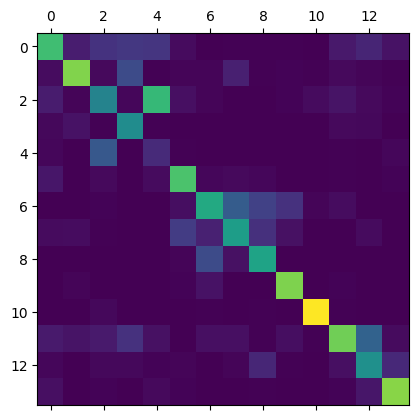

In [4]:
# We will define the frequecy matrix for anchor points for which we have information about their noisy labeling. 
# That is those points for wich the true label is known and we have its noisy label. 
# This permits estimating the transition matrix.
Anchors_train_df =  Train_df = (
    clean_train_key_list
        .merge(noisy_label_kv, on="image_dir", how="left")
        .merge(clean_label_kv, on="image_dir", how="left")
)
print(Anchors_train_df.head(10))

#Now we count the frequencies N_{ij} = sum (w=e_i and y = e_j)
freq_matrix = pd.crosstab(
    Anchors_train_df["noisy_label"],
    Anchors_train_df["clean_label"]
)
#And now we calculate the 
frequency = freq_matrix.to_numpy()
column_sum = frequency.sum(axis=0,keepdims=True)

#Normalizing the matrix to obtain the estimated transition probabilities
M = frequency/column_sum
print("\nThe sum of each M's column:\n", M.sum(axis=0))

plt.matshow(M)


### Preparing the datsets and dataloaders that feed the training loop.

In [5]:
# Train dataset has only noisy labels, so we merge the noisy_train_key_list with the noisy_label_kv to obtain a dataframe with the direction of each image and its corresponding noisy label.
Train_df = (
    noisy_train_key_list
        .merge(noisy_label_kv, on="image_dir", how="left")
)
len(Train_df)
Train_df.head()


,image_dir,noisy_label
0,"images/3/25/2958943246,951512325.jpg",0
1,"images/4/72/461537309,942133472.jpg",0
2,"images/7/13/4204850569,2103117713.jpg",0
3,"images/0/81/3754976883,1136919081.jpg",0
4,"images/0/96/2890714614,3776307096.jpg",0


In [6]:
# Test dataset has only clean labels, so we do the same for the test set, but in this case we merge the clean_test_key_list with the clean_label_kv to obtain a dataframe with the direction of each image and its corresponding clean label.
Test_df = (
    clean_test_key_list
        .merge(clean_label_kv, on="image_dir", how="left")
)
len(Test_df)
Test_df.head()


,image_dir,clean_label
0,"images/0/00/1278541879,867148000.jpg",13
1,"images/0/00/1298176222,2755628000.jpg",11
2,"images/0/00/1761426484,4024076000.jpg",12
3,"images/0/00/1992782016,1485508000.jpg",11
4,"images/0/00/2281045900,1423836000.jpg",6


In [ ]:
# And we create a class that generates the dataset, with this we can the create the dataloaders for the training and test sets.
# We include two possibilities:
#   Labels: one-hot encoding or integer labels
#   Images: flattened or not (for the case of using an MLP. This is not recommended because of the size of Clothing1M. Using an MLP with flattened images would require a lot of memory and computational resources. However, the option is there if you want to experiment with it.)
# We use the standard image transform for imagenet, that is, normalizing the channels to ImageNet mean/std. (I think this is standard practice specifically if using pretarained ResNet50)
class ClothingDataset(Dataset):
    """
    Training dataset. Generates a dataloader:
    Inputs:
        - df: Dataframe with two columns (path to image | labele )
        - root_dir: Path to the clothing folder
        - train: Boolean (True for the train set)
        - num_classes: This is fixed for clothing dataset to 14.
        - img_size: This is fixed for clothing dataset to 224.
        - flatten: Default = False. Whether to flatten the input features from image to vector
        - uniform_weights: Boolean (the weights for PICO loss)
    Returns:
        (x, w, v, c, y=None, idx)
    """
    def __init__(self, df, root_dir,# label_col,
                 train = True,
                 return_index = True,
                 num_classes = 14,
                 uniform_weights =  True,
                 #one_hot = True, 
                 img_size=224, flatten=False,):
        self.image_paths = df["image_dir"].values
        self.train = train
        if self.train:
            self.labels = df["noisy_label"].values
        else:
            self.labels = df["clean_label"].values
        self.root_dir = Path(root_dir)

        self.num_classes = num_classes
        self.return_index = return_index
        self.uniform_weights = uniform_weights


        # The standard image transform for imagenet and the one used in Dani's thesis 
        self.transform = transforms.Compose([
            transforms.Resize(256),            # Resize so the shorter side is 256
            transforms.CenterCrop(224),        # Crop the center 224×224 region
            transforms.ToTensor(),             # Convert PIL image to PyTorch tensor
            transforms.Normalize(              # Normalize channels to ImageNet mean/std
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        ])

        self.do_flatten = flatten
        self.flatten_layer = torch.nn.Flatten()

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.root_dir / self.image_paths[idx]
        label = int(self.labels[idx])

        image = Image.open(img_path).convert("RGB")
        image = self.transform(image)
        
        if self.do_flatten:
            image = self.flatten_layer(image)

        
        label_oh = F.one_hot(
            torch.tensor(label),
            num_classes=self.num_classes
            ).float()
        if self.train:
            if self.uniform_weights:
                c = torch.full(
                    (self.num_classes,),
                    1.0 / self.num_classes
                )
            else:
                #This is provisional cause idk what to do
                c = torch.full(
                    (self.num_classes,),
                    1.0 / self.num_classes
                )

            return image, label, label_oh, c, 0.0, torch.tensor(idx)
        else:
            return image, label_oh
        


In [8]:
train_dataset = ClothingDataset(
    df = Train_df,
    root_dir = root_dir,
    train = True,
    #one_hot = True,
    flatten = False      # This would be only for an MLP but Clothing is excesive big to do so. 
)

train_loader = DataLoader(
    train_dataset,
    batch_size = 64,
    shuffle = True,
    num_workers = 0,
    pin_memory = True
)


test_dataset = ClothingDataset(
    df = Test_df,
    root_dir = root_dir,
    train = False,
    #label_col = "clean_label",
    #one_hot = True,
    flatten = False      
)

test_loader = DataLoader(
    test_dataset,
    batch_size = 64,
    shuffle = False,    
    num_workers = 0,
    pin_memory = True
)

In [9]:
xb, wb, vb, cb, yb, ib = next(iter(train_loader))
print(xb.shape)
print(wb.shape, wb[0]) 
print(vb.shape, vb[0])
print(cb.shape, cb[0])
print(yb.shape, yb[0])
print(ib.shape, ib[0])

torch.Size([64, 3, 224, 224])
torch.Size([64]) tensor(12)
torch.Size([64, 14]) tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.])
torch.Size([64, 14]) tensor([0.0714, 0.0714, 0.0714, 0.0714, 0.0714, 0.0714, 0.0714, 0.0714, 0.0714,
        0.0714, 0.0714, 0.0714, 0.0714, 0.0714])
torch.Size([64]) tensor(0., dtype=torch.float64)
torch.Size([64]) tensor(911226)


In [ ]:
# We get the fist batch
train_images, train_labels, train_labels_oh, _, _, _ = next(iter(train_loader))
test_images, test_labels = next(iter(test_loader))

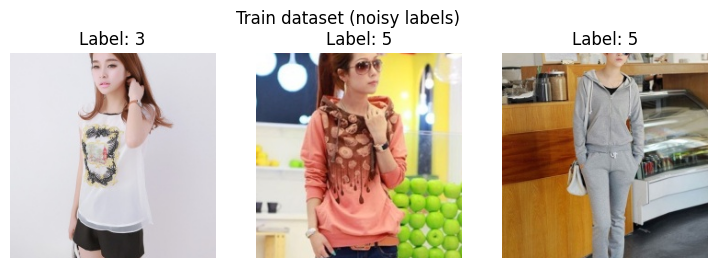

In [11]:
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

fig, axes = plt.subplots(1, 3, figsize=(9, 3))
fig.suptitle("Train dataset (noisy labels)")

for i in range(3):
    img = train_images[i].cpu()

    # Unnormalize
    img = img * IMAGENET_STD + IMAGENET_MEAN
    img = torch.clamp(img, 0, 1)

    # (C, H, W) → (H, W, C)
    img = img.permute(1, 2, 0)

    # ---- LABEL HANDLING (ROBUST) ----
    label = train_labels[i]

    if label.ndim == 0:              # integer label
        label_idx = label.item()
    else:                            # one-hot or probability vector
        label_idx = torch.argmax(label).item()

    axes[i].imshow(img)
    axes[i].set_title(f"Label: {label_idx}")
    axes[i].axis("off")

plt.show()

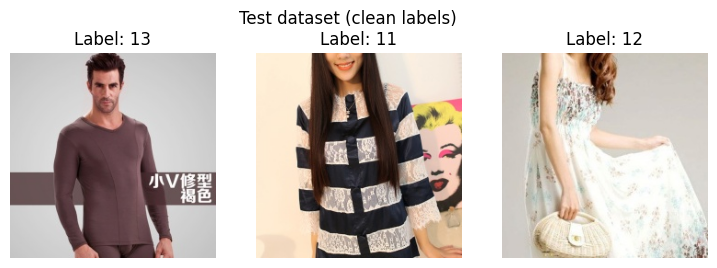

In [12]:


fig, axes = plt.subplots(1, 3, figsize=(9, 3))
fig.suptitle("Test dataset (clean labels)")

for i in range(3):
    img = test_images[i].cpu()

    # Unnormalize
    img = img * IMAGENET_STD + IMAGENET_MEAN
    img = torch.clamp(img, 0, 1)

    # (C, H, W) → (H, W, C)
    img = img.permute(1, 2, 0)

    # ---- LABEL HANDLING (ROBUST) ----
    label = test_labels[i]

    if label.ndim == 0:              # integer label
        label_idx = label.item()
    else:                            # one-hot or probability vector
        label_idx = torch.argmax(label).item()

    axes[i].imshow(img)
    axes[i].set_title(f"Label: {label_idx}")
    axes[i].axis("off")

plt.show()

In [ ]:
print("Train batch:", train_images.shape, train_labels.shape, train_labels_oh.shape)
print("Test batch:", test_images.shape, test_labels.shape)
print("Label values (train):", train_labels[:10])
print("Label values one hot encoding (train):", train_labels_oh[:10])

Train batch: torch.Size([64, 3, 224, 224]) torch.Size([64]) torch.Size([64, 14])
Test batch: torch.Size([64, 3, 224, 224]) torch.Size([64]) torch.Size([64, 14])
Label values (train): tensor([ 3,  5,  5,  6,  1,  2,  4,  1,  5, 12])
Label values one hot encoding (train): tensor([[0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.]])


In [14]:
M.shape

(14, 14)

In [15]:
class Data_handling:
    """
    Container class for datasets, dataloaders, and weak-label metadata.
    """

    def __init__(
        self,
        train_loader,
        test_loader,
        num_classes,
        transition_matrix=None,
        weakener=None,
        input_shape=(3, 224, 224),
        device=None,
    ):
        self.train_loader = train_loader
        self.test_loader = test_loader
        self.num_classes = num_classes
        self.transition_matrix = transition_matrix
        self.weakener = weakener
        self.input_shape = input_shape

        self.device = device or torch.device(
            "cuda" if torch.cuda.is_available() else "cpu"
        )

        # Derived attributes
        self.train_size = len(train_loader.dataset)
        self.test_size = len(test_loader.dataset)

    def to(self, device):
        self.device = device
        return self

In [16]:
Data = Data_handling(
    train_loader=train_loader,
    test_loader=test_loader,
    num_classes=14,
    transition_matrix=torch.tensor(M, dtype=torch.float32)
)

In [17]:
# ##########################
# Define model and optimizer
def get_model(Data, opt_alg='adam', lr=1e-6, momentum=0.9):
    """ Define model and optimizer
    Parameters
        Data: dataset object with num_classes and num_features attributes
    Returns
        model: the neural network model
        optimizer: the optimizer
    """
    model = ResNet50(fine_tune_all=False)

    if opt_alg == 'adam':
        optimizer = optim.Adam(model.parameters(), lr=lr)
    elif opt_alg == 'sgd':
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=momentum)
    else:
        raise ValueError(f"Unsupported optimizer: {opt_alg}") 

    return model, optimizer

# ########################
# Visualization of results
def plot_results(results_df):
    """ Plot training results
    Parameters
        results_df: DataFrame with training results
    """

    # Set up a wide figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

    # Loss curves
    ax1.plot(results_df['epoch'], results_df['train_loss'], label='Train Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Loss Curve')
    ax1.legend()
    ax1.grid(True)

    # Accuracy curves
    ax2.plot(results_df['epoch'], results_df['train_acc'], label='Train Accuracy')
    ax2.plot(results_df['epoch'], results_df['test_acc'], label='Test Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_title('Accuracy Curves')
    ax2.legend()
    ax2.grid(True)
    plt.tight_layout()
    plt.show()

In [18]:
def run_simulation(Data, loss, num_epochs=10, optimizer_name='adam', 
                   loss_code=None, pseudolabel_model=None, lr=1e-6, corr_p=0.2,
                   phi=0.8):
    """Run a training simulation with the specified parameters.

    Parameters
    ----------
    Data : dataset object
        The dataset object containing training and test data.
    loss : loss function object
        The loss function to use for training.
    num_epochs : int, optional
        The number of training epochs (default is 10).
    optimizer_name : str, optional
        The name of the optimizer to use (default is 'adam').
    loss_code : str, optional
        A code representing the loss function (for metadata) (default is None).
    pseudolabel_model : str, optional
        A string indicating the pseudolabel model used (for metadata)
        (default is None).
    lr : float, optional
        The learning rate for the optimizer (default is 1e-6).
    corr_p : float, optional
        The corruption probability used in the weak label generation 
        (for metadata) (default is 0.2).
    phi : float, optional
        The phi parameter for the training loop (default is 0.8).
    """

    # 1. Get model and optimizer
    model, optimizer = get_model(Data, opt_alg=optimizer_name, lr=lr)

    # 2. Run the training + evaluation loop
    model, results_df = clothing_train_and_evaluate(
        model, train_loader, test_loader, optimizer, loss, num_epochs,
        phi=phi, pseudolabel_model=pseudolabel_model)

    # 3. Save simultation attributes in a metadata dictionary
    metadata = {'pseudo_label_model': pseudolabel_model, 'loss_name': loss_code, 
                'corr_p': corr_p, 'optimizer': type(optimizer).__name__,
                'initial_lr': optimizer.param_groups[0]['lr'], 'phi': phi}
    print(pd.DataFrame([metadata]).T)

    # 4. View the epoch‐by‐epoch results
    plot_results(results_df)

    return model, optimizer, metadata, results_df

In [19]:
# #####################################
# Common parameters for all simulations

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Training parameters
num_epochs = 10
optimizer_name = 'adam'
lr = 1e-6

Using device: cuda


In [ ]:
# #################
# Testing IR Loss

loss_code = "cross_entropy"
loss = IRLoss(Data.transition_matrix, loss_code=loss_code)
pseudolabel_model = 'IR'

model, optimizer, metadata, results_df = run_simulation(
    Data, loss, num_epochs=num_epochs, optimizer_name=optimizer_name, 
    loss_code=loss_code, pseudolabel_model=pseudolabel_model, lr=lr,
    corr_p=0.5)

results_df.head(num_epochs)

In [ ]:
# #################
# Testing PiCO Loss

loss_code = "cross_entropy"
loss = PiCOLoss(loss_code=loss_code)
pseudolabel_model = 'PiCO'
phi = 0.8

model, optimizer, metadata, results_df = run_simulation(
    Data, loss, num_epochs=num_epochs, optimizer_name=optimizer_name, 
    loss_code=loss_code, pseudolabel_model=pseudolabel_model, lr=lr,
    corr_p=0.5, phi=phi)

results_df.head(num_epochs)

In [ ]:
# #################
# Marginal Chain

loss_code = "cross_entropy"
loss = MarginalChainProperLoss(M, loss_code=loss_code)
pseudolabel_model = 'MC'

model, optimizer, metadata, results_df = run_simulation(
    Data, loss, num_epochs=num_epochs, optimizer_name=optimizer_name, 
    loss_code=loss_code, pseudolabel_model=pseudolabel_model, lr=lr,
    corr_p=0.5, phi=phi)

results_df.head(num_epochs)

In [ ]:
# #################
# Forward Proper Loss

loss_code = "cross_entropy"
loss = ForwardProperLoss(M, loss_code=loss_code)
pseudolabel_model = 'FWD'

model, optimizer, metadata, results_df = run_simulation(
    Data, loss, num_epochs=num_epochs, optimizer_name=optimizer_name, 
    loss_code=loss_code, pseudolabel_model=pseudolabel_model, lr=lr,
    corr_p=0.5, phi=phi)

results_df.head(num_epochs)

In [ ]:
# ############
# Majorization-Minimization (Uppder bound)

loss_code = "cross_entropy"
loss = UpperBoundWeakProperLoss(M, loss_code=loss_code)
pseudolabel_model = 'MM'

model, optimizer, metadata, results_df = run_simulation(
    Data, loss, num_epochs=num_epochs, optimizer_name=optimizer_name, 
    loss_code=loss_code, pseudolabel_model=pseudolabel_model, lr=lr,
    corr_p=0.1, phi=phi)

results_df.head(num_epochs)

In [ ]:
loss_code = "ps_2"
loss = UpperBoundWeakProperLoss(M, loss_code=loss_code)
pseudolabel_model = 'MM'


model, optimizer, metadata, results_df = run_simulation(
    Data, loss, num_epochs=num_epochs, optimizer_name=optimizer_name, 
    loss_code=loss_code, pseudolabel_model=pseudolabel_model, lr=lr)

results_df.head(num_epochs)

In [ ]:
loss_code = "tsallis_0.2"
loss = UpperBoundWeakProperLoss(M, loss_code=loss_code)
pseudolabel_model = 'MM'

model, optimizer, metadata, results_df = run_simulation(
    Data, loss, num_epochs=num_epochs, optimizer_name=optimizer_name, 
    loss_code=loss_code, pseudolabel_model=pseudolabel_model, lr=lr)

results_df.head(num_epochs)

In [ ]:
loss_code = "spherical"
loss = UpperBoundWeakProperLoss(M, loss_code=loss_code)
pseudolabel_model = 'MM'

model, optimizer, metadata, results_df = run_simulation(
    Data, loss, num_epochs=num_epochs, optimizer_name=optimizer_name, 
    loss_code=loss_code, pseudolabel_model=pseudolabel_model, lr=lr)

results_df.head(num_epochs)